In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_nature_box_style():
    mpl.rcParams.update({
        # Figure
        "figure.figsize": (3.5, 2.5),
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        # Fonts
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,

        # Axes (ALL spines on)
        "axes.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.spines.left": True,
        "axes.spines.bottom": True,

        # Ticks
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,

        # Lines
        "lines.linewidth": 1.2,

        # Legend
        "legend.frameon": False,
        "legend.fontsize": 7,

        # Math text
        "mathtext.default": "regular"
    })


In [3]:
set_nature_box_style()

9.221556886227546


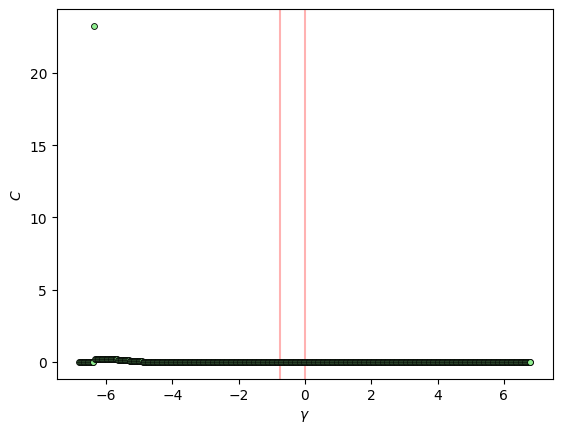

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import json

group_name = "S108"
trial = 67

with open(f"data_ANALYSIS_for_{group_name}_trialNum{trial}.json", "r") as file:
    data = json.load(file)

betas = np.array(data["beta_range"])
gammas = np.array(data["gamma_range"])[0]
u_crit = np.array(data["u_critical"])

N_val = 140
d_heat = 2*np.gradient(u_crit[N_val], gammas)*(u_crit[N_val])**3
print(betas[N_val])
plt.scatter(gammas, d_heat,     s=18,                 # marker size (pt^2)
    marker="o",
    facecolor="lightgreen",    # white fill (Nature common)
    edgecolor="black",
    linewidth=0.6,
    zorder=3)
plt.axvline(x=0, color = "red", alpha =0.3)
plt.axvline(x=-0.75, color = "red", alpha =0.3)
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$C$")
#plt.ylim(0,1)
#plt.yscale('log')
#plt.xlim(-0.3,0.3)
#plt.title(r"Heat Capacity vs $\gamma$ for $\mathbb{Z}$" + f"${N}$")
plt.savefig(f'ANALYSIS_for_{group_name}_trialNum{trial}_beta_val{betas[N_val]}.png', format='png', bbox_inches='tight')


#check that u has correct behaviour


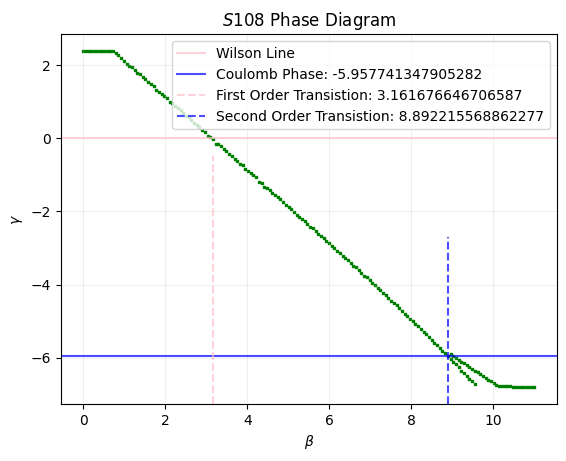

In [84]:
import numpy as np

def phase_diagram(observable, gamma_list, tol_steps = 1, eps = 1e-2):
    
    if np.allclose(observable, 0, rtol=eps):
        return [np.nan, np.nan]
    else:
        left_plane = np.zeros(len(observable))
        index_first_order = np.argmax(observable)
        #print(index_first_order)
        if index_first_order-tol_steps > 1:
            left_plane = observable[0:index_first_order-tol_steps]
            left_gamma_plane = gamma_list[0:index_first_order-tol_steps]
            #print(index_first_order)
            second_order_guess_left = np.argmax(left_plane)
        else:
            left_plane = np.zeros(len(observable))
        if index_first_order < len(observable) - tol_steps - 1:
            right_plane = observable[index_first_order+tol_steps:-1]
            right_gamma_plane = gamma_list[index_first_order+tol_steps:-1]
            
            second_order_guess_right = np.argmax(right_plane)
        else:
            right_plane = np.zeros(len(observable))
        
        #print(right_plane, second_order_guess_right)
        
        if np.allclose(right_plane, 0, rtol = eps):
            if np.allclose(left_plane, 0, rtol = eps):
                return [gamma_list[index_first_order], np.nan]
            if np.isclose(gamma_list[index_first_order], left_gamma_plane[second_order_guess_left], rtol = 0.02):
                return [gamma_list[index_first_order], np.nan]
            else:
                return [gamma_list[index_first_order], left_gamma_plane[second_order_guess_left]]
        if np.isclose(gamma_list[index_first_order], right_gamma_plane[second_order_guess_right], rtol = 0.02):
            return [gamma_list[index_first_order], np.nan]
        else:
            return [gamma_list[index_first_order], right_gamma_plane[second_order_guess_right]]

heat_caps = []

for i,j in enumerate(betas):
    heat_caps.append(2*np.gradient(u_crit[i], gammas)*(u_crit[i])**3)

heat_caps = np.array(heat_caps)

phase_graph = []

for i, val in enumerate(heat_caps):

    phase_graph.append(phase_diagram(val, gammas))
   
   
c1 = [] 
c2 = []

for critical in phase_graph:
    c1.append(critical[0])
    c2.append(critical[1])

c2 = np.array(c2)
c1 = np.array(c1)

def merge_arrays(a, b, tol=1e-1):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if a.shape != b.shape:
        raise ValueError("Arrays must have the same shape")

    out = np.empty(a.shape, dtype=object)

    for idx in np.ndindex(a.shape):
        ai, bi = a[idx], b[idx]

        if np.isnan(ai) and np.isnan(bi):
            out[idx] = np.nan
        elif np.isnan(ai):
            out[idx] = bi
        elif np.isnan(bi):
            out[idx] = ai
        else:
            if np.isclose(ai, bi, atol=tol, rtol=0):
                out[idx] = 0.5 * (ai + bi)
            else:
                out[idx] = [ai, bi]

    return out

def scatter_merged(x, merged, jitter=0.0):
    x = np.asarray(x)
    
    x_plot = []
    y_plot = []
    
    for xi, yi in zip(x, merged):
        if isinstance(yi, list) or isinstance(yi, tuple):
            # two points
            if jitter > 0:
                x_plot.extend([xi - jitter, xi + jitter])
            else:
                x_plot.extend([xi, xi])
            y_plot.extend(yi)
        elif np.isnan(yi):
            continue
        else:
            x_plot.append(xi)
            y_plot.append(yi)
    
    plt.figure()
    plt.scatter(x_plot, y_plot, marker = "s", color = "green", s=2)
    #plt.xlabel("x")
    #plt.ylabel("y")
    #plt.title("Merged Scatter Plot")

    
c3 = merge_arrays(c1, c2)
def index_before_first_branch(arr):
    for i, val in enumerate(arr):
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 2:
            return i - 1  # index before first branch
    
    return None  # no branch found
def index_closest_to_zero(arr):
    best_idx = None
    best_val = np.inf
    
    for i, val in enumerate(arr):
        if isinstance(val, (list, tuple, np.ndarray)):
            # check both values
            for v in val:
                if not np.isnan(v) and abs(v) < best_val:
                    best_val = abs(v)
                    best_idx = i
        else:
            if not np.isnan(val) and abs(val) < best_val:
                best_val = abs(val)
                best_idx = i
    
    return best_idx

scatter_merged(betas, c3)
#print(len(c3))
#plt.scatter(betas, c1, marker = ".", color = "black", s=2)    
#plt.scatter(betas, c3, marker = ".", color = "black", s=2)
plt.axhline(y=0, color ="pink", alpha = 0.7, label = "Wilson Line")
plt.axhline(y=c3[index_before_first_branch(c3)], color = "blue", alpha = 0.7, label = f"Coulomb Phase: {c3[index_before_first_branch(c3)]}")
plt.axvline(x=betas[index_closest_to_zero(c3)], color ="pink", alpha = 0.7, ls = "--", label = f"First Order Transistion: {betas[index_closest_to_zero(c3)]}", ymax= 0.67)
plt.axvline(x=betas[index_before_first_branch(c3)], color ="blue", alpha = 0.7, ls = "--", label = f"Second Order Transistion: {betas[index_before_first_branch(c3)]}", ymax= 0.45)
plt.title(rf"${group_name}$ Phase Diagram")
plt.legend()
plt.grid(alpha =0.2)
#plt.xlim(0,5)
#plt.ylim(-0.31,0.14)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
#plt.savefig("s648_phase_diagram_1_intial.png")
plt.savefig(f'{group_name}_phase_diagram_2_intial.png', dpi=600)

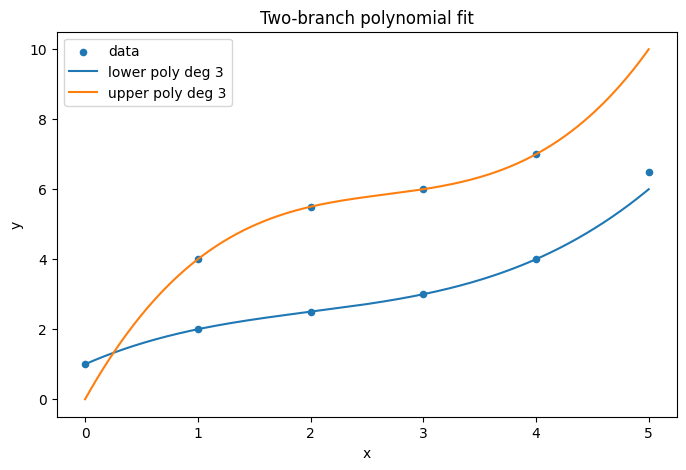

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def unpack_merged_points(x, merged):
    x_single, y_single = [], []
    x_double, y_double1, y_double2 = [], [], []

    for xi, yi in zip(x, merged):
        if isinstance(yi, (list, tuple, np.ndarray)):
            if len(yi) != 2:
                raise ValueError("Each multi-valued entry must have length 2")
            x_double.append(xi)
            y_double1.append(yi[0])
            y_double2.append(yi[1])
        elif np.isnan(yi):
            continue
        else:
            x_single.append(xi)
            y_single.append(yi)

    return (
        np.array(x_single, dtype=float),
        np.array(y_single, dtype=float),
        np.array(x_double, dtype=float),
        np.array(y_double1, dtype=float),
        np.array(y_double2, dtype=float),
    )

def fit_two_branches(x, merged, deg=8, close_tol=None, plot=True):
    x_single, y_single, x_double, y1, y2 = unpack_merged_points(x, merged)

    # Assign single-valued points to midpoint branch if present
    # and use double-valued points for lower/upper branches
    x_lower = x_double.copy()
    y_lower = np.minimum(y1, y2)

    x_upper = x_double.copy()
    y_upper = np.maximum(y1, y2)

    if len(x_lower) < deg + 1 or len(x_upper) < deg + 1:
        raise ValueError("Not enough points for requested polynomial degree")

    p_lower = np.poly1d(np.polyfit(x_lower, y_lower, deg))
    p_upper = np.poly1d(np.polyfit(x_upper, y_upper, deg))

    if plot:
        plt.figure(figsize=(8, 5))

        # original points
        all_x = []
        all_y = []
        for xi, yi in zip(x, merged):
            if isinstance(yi, (list, tuple, np.ndarray)):
                all_x.extend([xi, xi])
                all_y.extend(yi)
            elif np.isnan(yi):
                continue
            else:
                all_x.append(xi)
                all_y.append(yi)

        plt.scatter(all_x, all_y, s=20, label="data")

        xx = np.linspace(np.nanmin(x), np.nanmax(x), 1000)
        plt.plot(xx, p_lower(xx), label=f"lower poly deg {deg}")
        plt.plot(xx, p_upper(xx), label=f"upper poly deg {deg}")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Two-branch polynomial fit")
        plt.legend()
        plt.show()

    return p_lower, p_upper

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
merged = np.array([
    1.0,
    [2.0, 4.0],
    [2.5, 5.5],
    [3.0, 6.0],
    [4.0, 7.0],
    6.5
], dtype=object)

p_lo, p_hi = fit_two_branches(x, merged, deg=3)

/tmp/ipykernel_9608/2649624325.py:27: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, degree)


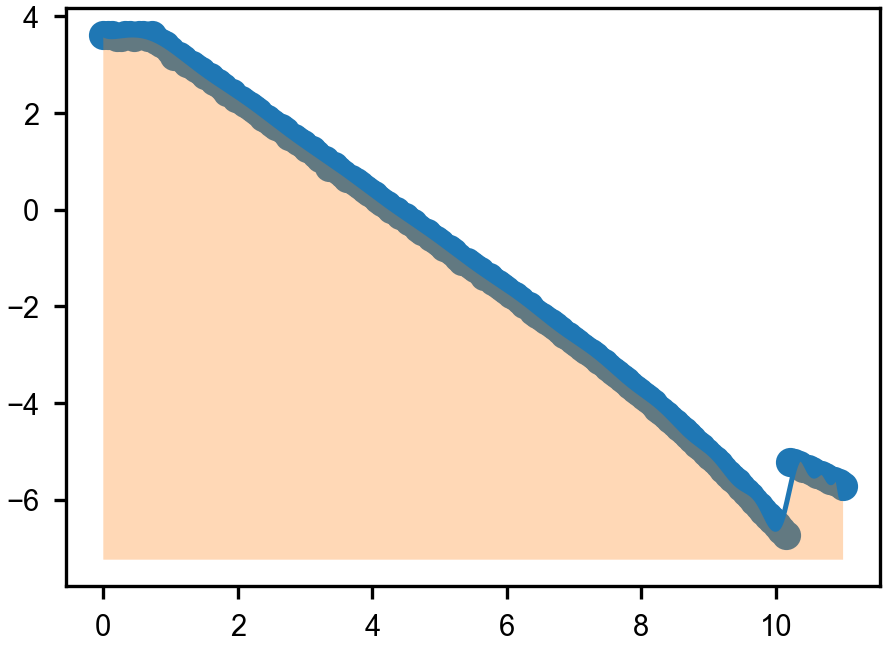

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_with_poly_shading(x, y, degree=5, shade='above'):
    """
    Scatter plot with polynomial trendline and shaded region.

    Parameters
    ----------
    x : array-like
    y : array-like
    degree : int
        Polynomial degree for fitting
    shade : str
        'above' or 'below'
    """

    x = np.asarray(x)
    y = np.asarray(y)

    fig, ax = plt.subplots()

    # scatter
    ax.scatter(x, y)

    # polynomial fit
    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)

    # dense grid for smooth curve
    x_dense = np.linspace(x.min(), x.max(), 1000)
    y_curve = poly(x_dense)

    # plot curve
    ax.plot(x_dense, y_curve)

    # get axis limits
    ymin, ymax = ax.get_ylim()

    # shading
    if shade == 'above':
        ax.fill_between(x_dense, y_curve, ymax, where=ymax >= y_curve, alpha=0.3)
    elif shade == 'below':
        ax.fill_between(x_dense, ymin, y_curve, where=y_curve >= ymin, alpha=0.3)

    plt.show()
    
scatter_with_poly_shading(betas, c1, degree=100,shade = "below")

In [23]:
test = np.array([1.2,1,1])

print(np.allclose(test, 1, rtol=0.2))

True


/tmp/ipykernel_6038/4202502259.py:24: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(beta_c1, group_size, poly_degree)


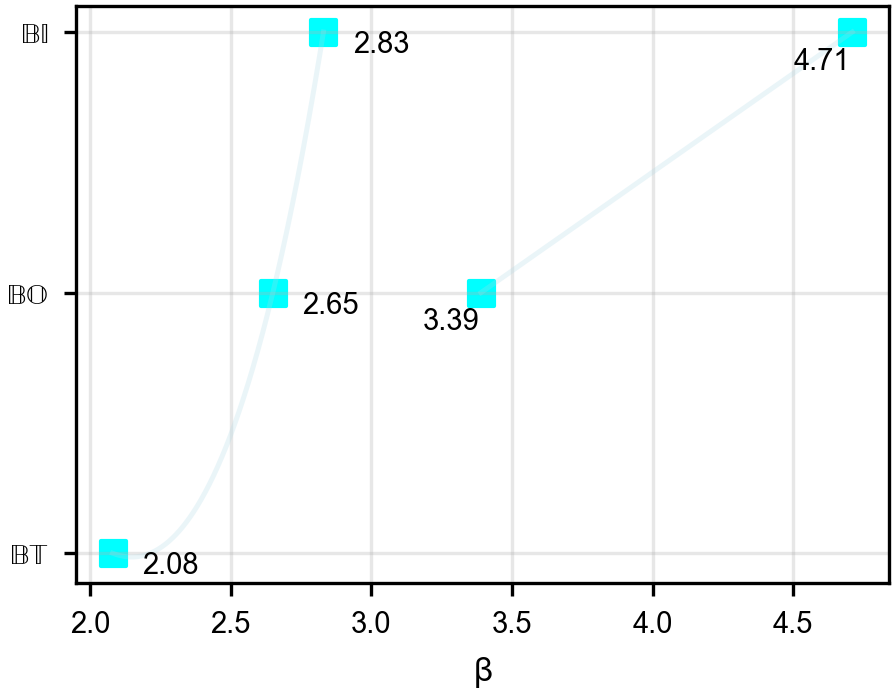

In [110]:
from scipy.optimize import curve_fit

beta_c1 = np.array([2.08, 2.65, 2.83])
beta_c2 = np.array([np.nan, 3.39, 4.71])
beta_c2star = np.array([3.39, 4.71])
group_size = np.array([7,8,9])
group_size2 = np.array([8,9])

plt.scatter(beta_c1, group_size,  color = "cyan", marker = "s")
plt.scatter(beta_c2, group_size, color = "cyan", marker = "s")

for xi, yi in zip(beta_c1, group_size):
    plt.annotate(f"{xi}", (xi, yi), textcoords="offset points", xytext=(7, -5), fontsize = 7)
for xi, yi in zip(beta_c2, group_size):
    plt.annotate(f"{xi}", (xi, yi), textcoords="offset points", xytext=(-14, -9), fontsize = 7)

word_labels = [r"$\mathbb{BT}$",r"$\mathbb{BO}$",r"$\mathbb{BI}$"]    
plt.yticks(group_size, word_labels)
plt.grid(True, alpha = 0.3)
plt.xlabel(r"$\beta$")
poly_degree = 4   # quadratic; change to 1, 3, 4, ...

# Fit coefficients (highest power first)
coeffs = np.polyfit(beta_c1, group_size, poly_degree)

# Polynomial object (clean + reusable)
poly_fit = np.poly1d(coeffs)

x_fit = np.linspace(beta_c1.min(), beta_c1.max(), 300)
y_fit = poly_fit(x_fit)

# Fitted exponential curve
plt.plot(
    x_fit, y_fit,
    color="lightblue",
    linewidth=1.2,
    alpha = 0.25
)

########
# popt, pcov = curve_fit(
#     exp_model,
#     beta_c2star,
#     group_size2,
#     p0=initial_guess
# )

# A_fit, k_fit = popt
# A_err, k_err = np.sqrt(np.diag(pcov))
# x_fit = np.linspace(beta_c2star.min(), beta_c2star.max(), 300)
# y_fit = exp_model(x_fit, A_fit, k_fit)
poly_degree = 1

coeffs = np.polyfit(beta_c2star, group_size2, poly_degree)

# Polynomial object (clean + reusable)
poly_fit = np.poly1d(coeffs)

x_fit = np.linspace(beta_c2star.min(), beta_c2star.max(), 300)
y_fit = poly_fit(x_fit)

plt.plot(
    x_fit, y_fit,
    color="lightblue",
    linewidth=1.2,
    alpha = 0.25
)

plt.savefig('phase_plot_BN.svg', format='svg', bbox_inches='tight')